# 3. Линейная регрессия.

Упражнения из **3 главы** книги [Введение в статистическое обучение](http://www-bcf.usc.edu/~gareth/ISL/) Гарета Джеймса, Даниела Уиттена, Тревора Хасти, Роберта Тибширани, Джонатана Тейлора.

## Практические задания.

### Задание 8.

Этот пункт предполагает использование простой линейной регресси применительно к набору данных Auto.

(a) Воспользуйтесь функцией sm.OLS() для постороения простой линеной регресси с переменной mpg в качестве отклика и horsepower в качестве предиктора. Вызовите функцию summarize() для вывода результатов. Прокомментируйте результирующие данные, например на основе следующих вопросов:

- i) существует ли зависимость между предиктором и откликом?

- ii) насколько сильна зависимость между предиктором и откликом?

- iii) является ли зависимость между предиктором и иоткликом положительной или отрицательной?

- iv) каким будет значение отклика mpg для значеная предиктора horsepower, равного 98? Какими будут 95-процентный доверительный интеврал и интервал предсказания?

In [1238]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [1239]:
def draw_inf(model, X, y):
    fig, ax = plt.subplots(2, 2, figsize = (10, 10))

    #График остатков
    pred_y = model.predict(X)
    residuals = y - pred_y
    ax[0, 0].scatter(pred_y, residuals)
    ax[0, 0].set(xlabel = 'Предсказанное значение', ylabel = 'Остатки')
    
    #График стьюдентизированных остатков
    influence = model.get_influence()
    studentized_residuals = influence.resid_studentized_internal
    ax[0, 1].scatter(pred_y, studentized_residuals)
    ax[0, 1].set(xlabel = 'Предсказанное значение', ylabel = 'Стьюдентезированные остатки')

    #График разбалансировки точки и значения остатка
    leverage = influence.hat_matrix_diag
    ax[1, 0].scatter(leverage, studentized_residuals)
    ax[1, 0].set(xlabel = 'Разбалансировка', ylabel = 'Стьюдентезированные остатки')
    

In [1240]:
auto = load_data('Auto')

In [1241]:
X = pd.DataFrame({'intercept': np.ones(auto.shape[0]),
                 'horsepower': auto['horsepower']})
y = auto['mpg']

In [1242]:
X.head()

,intercept,horsepower
name,,
chevrolet chevelle malibu,1.0,130
buick skylark 320,1.0,165
plymouth satellite,1.0,150
amc rebel sst,1.0,150
ford torino,1.0,140


In [1243]:
y.head()

name
chevrolet chevelle malibu    18.0
buick skylark 320            15.0
plymouth satellite           18.0
amc rebel sst                16.0
ford torino                  17.0
Name: mpg, dtype: float64

In [1244]:
from sklearn.model_selection import train_test_split

In [1245]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [1246]:
model = sm.OLS(y_train, X_train)
result = model.fit()

In [1247]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     455.7
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           4.55e-60
Time:                        17:27:25   Log-Likelihood:                -823.78
No. Observations:                 274   AIC:                             1652.
Df Residuals:                     272   BIC:                             1659.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     41.0848      0.869     47.255      0.0

In [1248]:
from sklearn.metrics import mean_squared_error

In [1249]:
y_pred = result.predict(X_test)

In [1250]:
MSE = mean_squared_error(y_pred, y_test)

In [1251]:
MSE

24.55612355112515

In [1252]:
np.sqrt(MSE)

4.955413560049771

In [1253]:
result.conf_int( alpha = 0.05)

,0,1
intercept,39.373158,42.796513
horsepower,-0.181690,-0.151008


> i) p-значение мало => связь между предиткором и откликом есть.
> 
> ii) приувелечение horespower на 1, модель уменьшит mpg на -0.1663.
> 
> iii) зависимость отрицательная.
> 
> iv) mpg = 24.7826, 95-процентный доверительный интервал: [15.0984, 34.4667]

(b) Постройте график зависимости предиктора и отклика ис использованием нового объекта ax. Воспользуйтесь методом ax.axline() или функцией abline(), показанной в лабораторной работе, для отоброжения регрессионной линии, найденной по методу наименьших квадратов.

In [1254]:
def abline(ax, b, m, *args, **kwargs):
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

C:\Users\10\AppData\Local\Temp\ipykernel_210528\1997005939.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, result.params[0], result.params[1], 'r--');


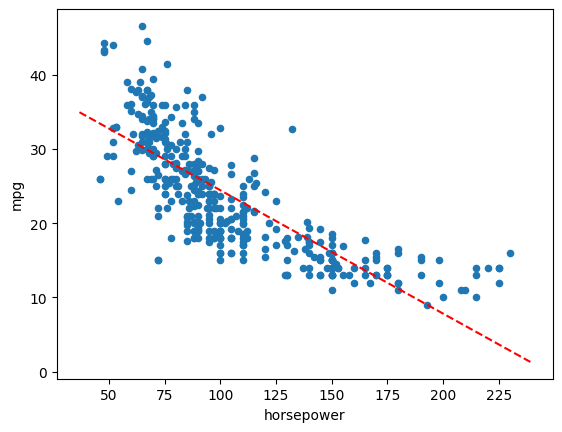

In [1255]:
ax = auto.plot.scatter('horsepower', 'mpg')
abline(ax, result.params[0], result.params[1], 'r--');

(с) Постройте нескольк диагностических графиков на сонове регресси по методу наименьших квадратов, как было показано в лаборатоной работе. Опишите проблемы, обнаруженные в этой модели. 

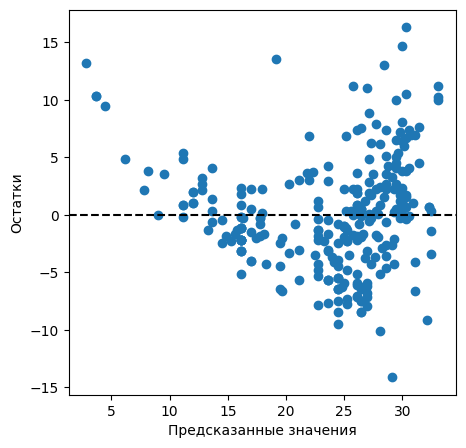

In [1256]:
ax = plt.subplots(figsize = (5, 5))[1]
ax.scatter(result.fittedvalues, result.resid)
ax.set_xlabel('Предсказанные значения')
ax.set_ylabel('Остатки')
ax.axhline(0, c='k', ls = '--')

Опираясь на график остатков, можно сделать вывод о ниленейности связи меджу откликом и предиктором.

105

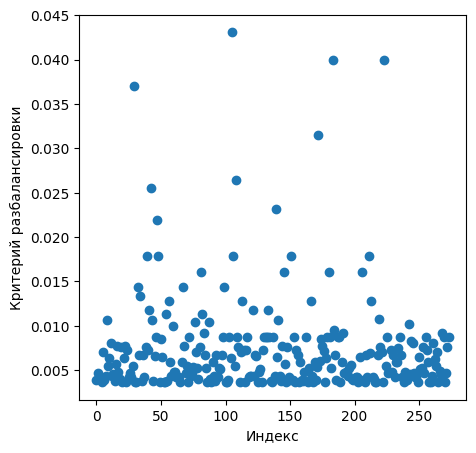

In [1257]:
infl = result.get_influence()
ax = plt.subplots(figsize = (5,5))[1]
ax.scatter(np.arange(X_train.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Индекс')
ax.set_ylabel('Критерий разбалансировки')
np.argmax(infl.hat_matrix_diag)

Опираясь на график, можно сделать вывод, что у нас есть несколь выбросов.

### Задание 9.

Этот пункт предполагет использование множественной линейной регресси применительно к набору данных Auto.

(a) Постройте матрицу диаграмм рассеяния, включающую все переменные из набора данных.

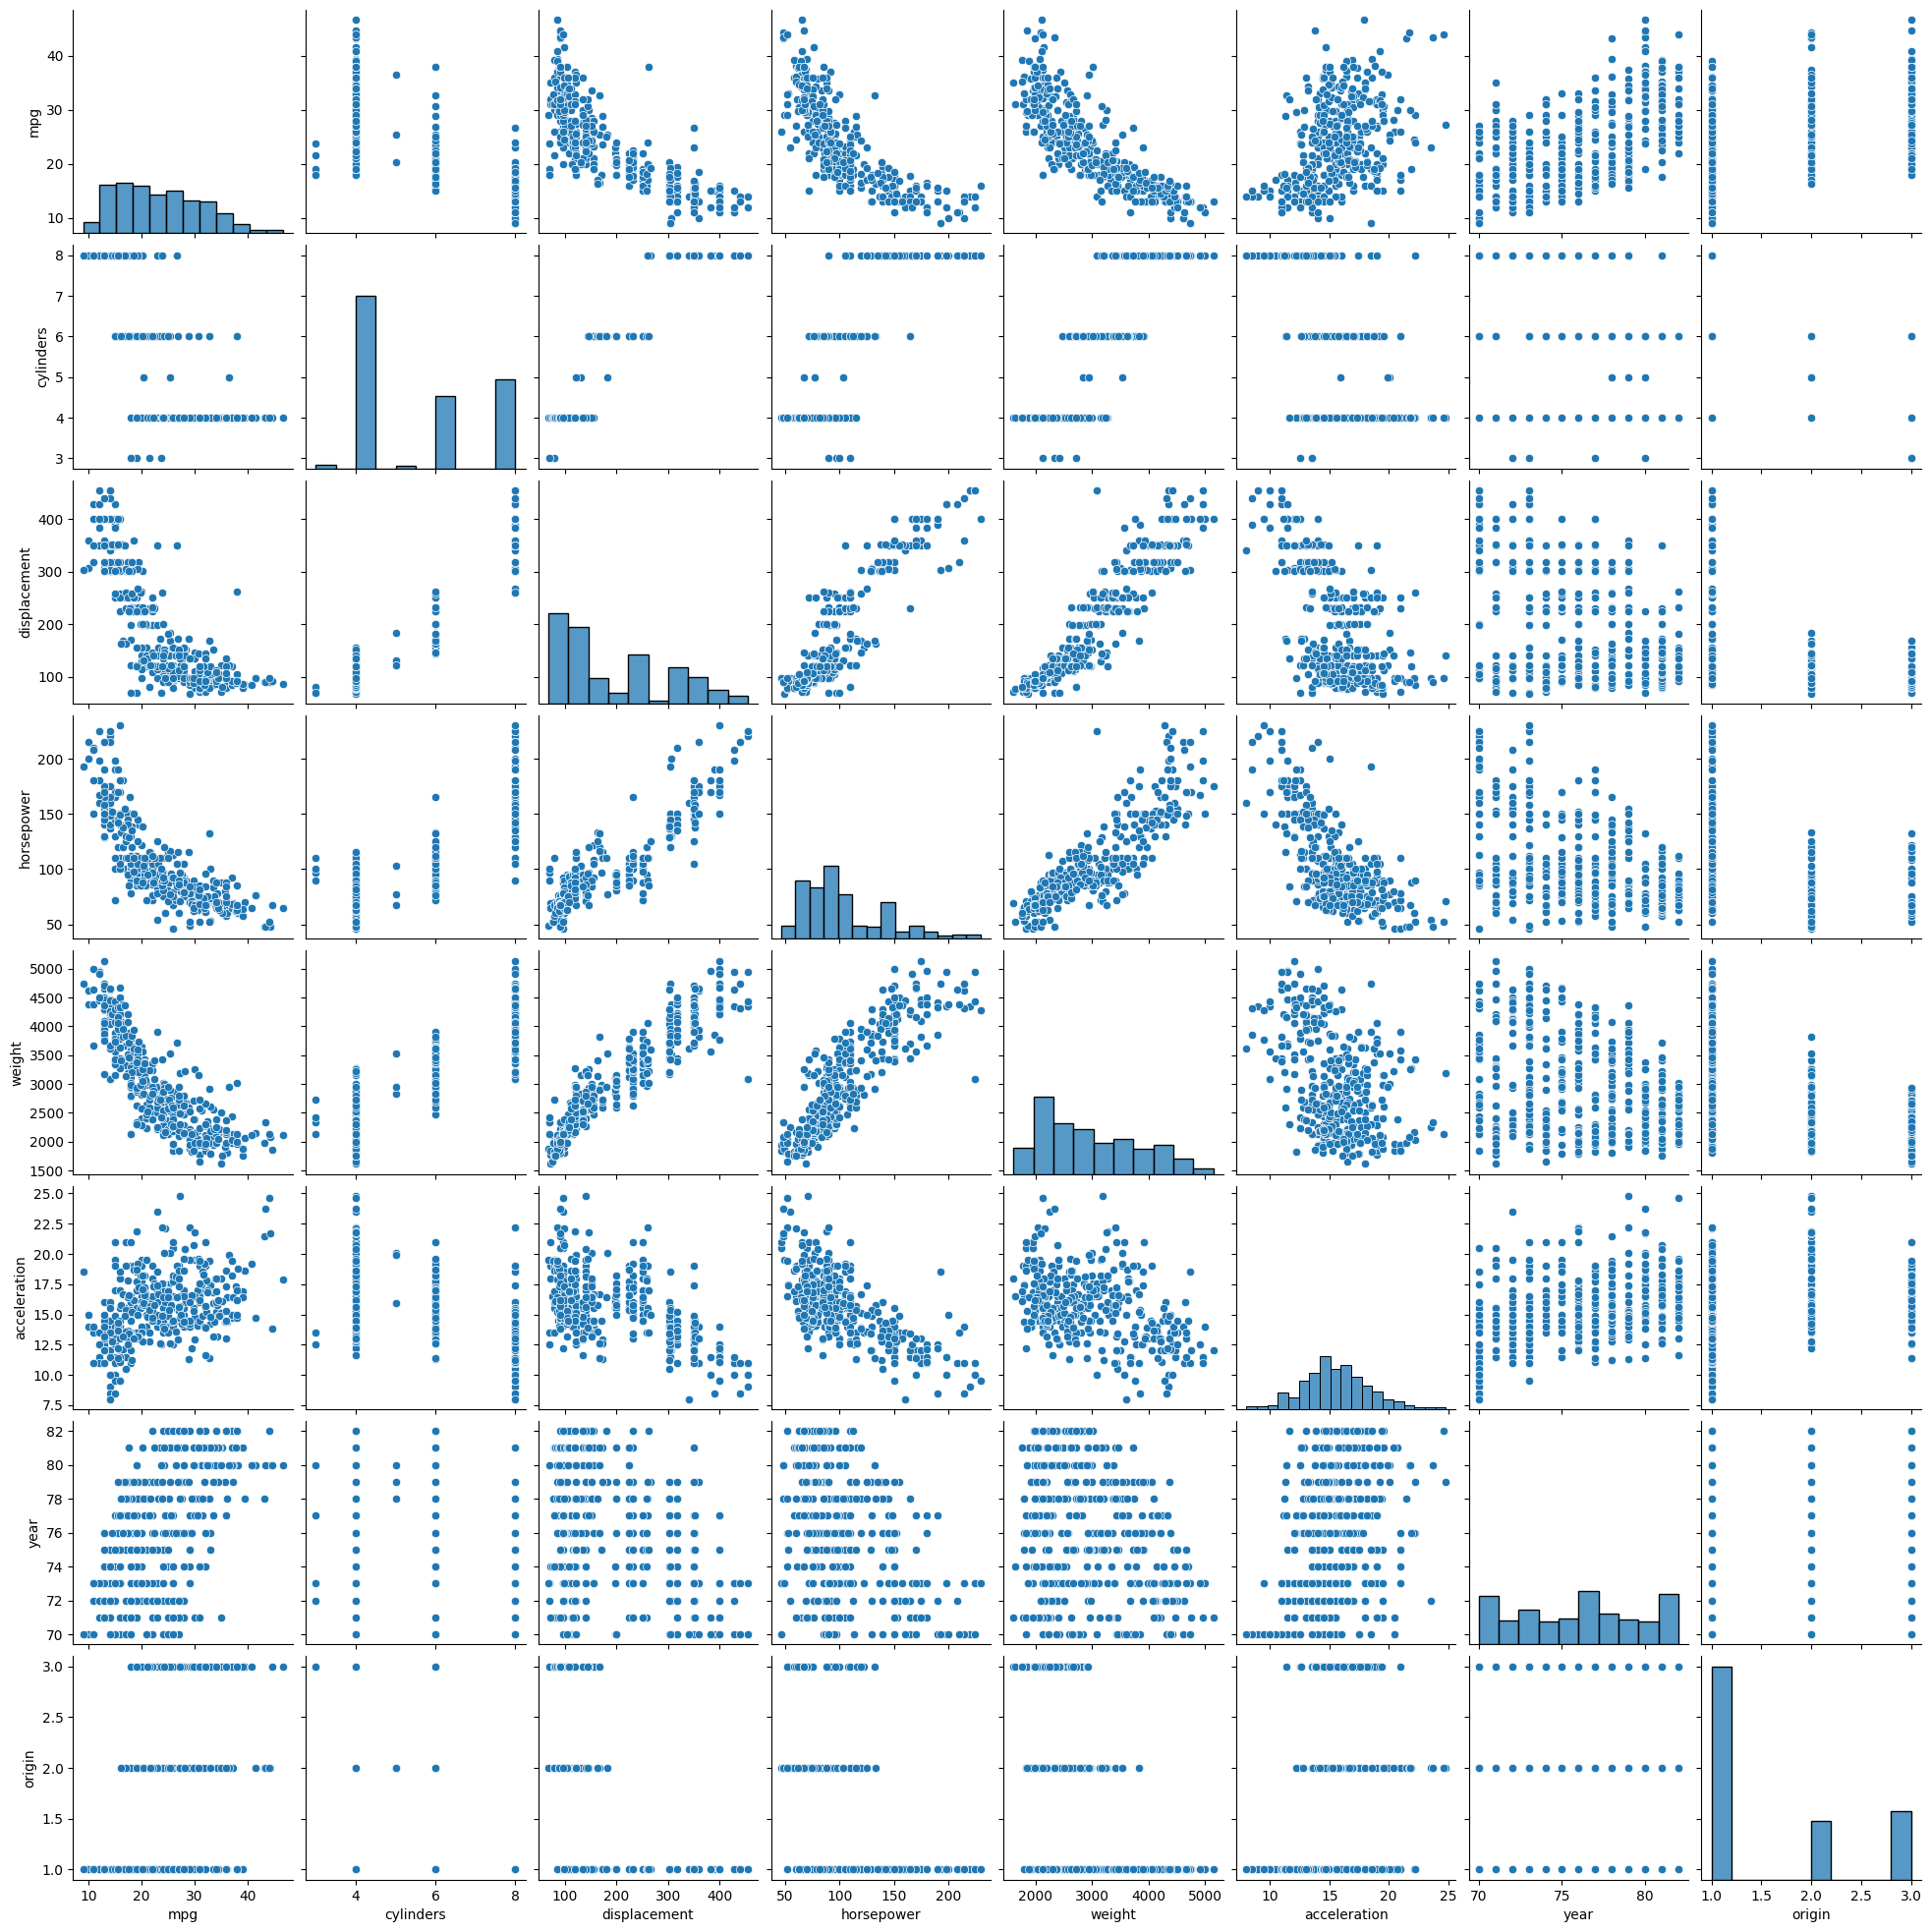

In [1258]:
sns.pairplot(auto)

(b) Рассчитайте корреляционную матрицу для все переменных

In [1259]:
auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [1260]:
auto.corr()['mpg'].sort_values()

weight         -0.832244
displacement   -0.805127
horsepower     -0.778427
cylinders      -0.777618
acceleration    0.423329
origin          0.565209
year            0.580541
mpg             1.000000
Name: mpg, dtype: float64

(c) Примените функцию sm.OLS() для подгонки множественной линейной регрессии с перменной mpg в качестве отклика и всеми оставшимися пермменными, за исключением name, в качестве предикторов. Воспользуйтесь функцией summarize() для вывода резельтатов. Прокомментирейте увиденное:

- i) существует ли зависимость между предикторами и откликом?
- ii) какие предикторы обладают статисчтически значимой взаимосвязью с откликом?
- iii) о чем говорит коэффициент перменной year?

In [1261]:
X = auto.drop('mpg', axis = 1)
y = auto['mpg']

In [1262]:
X = pd.get_dummies(data = X, columns = ['cylinders', 'origin'], drop_first = True, dtype = float)

In [1263]:
X.insert(0, 'intercept', np.ones(auto.shape[0]))

In [1264]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [1265]:
X_train

,intercept,displacement,horsepower,weight,acceleration,year,cylinders_4,cylinders_5,cylinders_6,cylinders_8,origin_2,origin_3
name,,,,,,,,,,,,
datsun 610,1.0,108.0,94,2379,16.5,73,1.0,0.0,0.0,0.0,0.0,1.0
ford maverick,1.0,200.0,85,2587,16.0,70,0.0,0.0,1.0,0.0,0.0,0.0
datsun 510 hatchback,1.0,119.0,92,2434,15.0,80,1.0,0.0,0.0,0.0,0.0,1.0
amc gremlin,1.0,199.0,90,2648,15.0,70,0.0,0.0,1.0,0.0,0.0,0.0
chevrolet nova,1.0,250.0,100,3336,17.0,74,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
amc matador (sw),1.0,304.0,150,3892,12.5,72,0.0,0.0,0.0,1.0,0.0,0.0
amc gremlin,1.0,232.0,100,2789,15.0,73,0.0,0.0,1.0,0.0,0.0,0.0
oldsmobile starfire sx,1.0,151.0,85,2855,17.6,78,1.0,0.0,0.0,0.0,0.0,0.0


In [1266]:
model_from_all_params = sm.OLS(y_train, X_train)

In [1267]:
result_from_all_params = model_from_all_params.fit()

In [1268]:
print(result_from_all_params.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     131.5
Date:                Thu, 24 Oct 2024   Prob (F-statistic):          6.95e-100
Time:                        17:27:30   Log-Likelihood:                -701.71
No. Observations:                 274   AIC:                             1427.
Df Residuals:                     262   BIC:                             1471.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -19.6717      5.909     -3.329   

In [1269]:
pred = result_from_all_params.predict(X_test)

In [1270]:
MSE = mean_squared_error(y_test, pred)

In [1271]:
MSE

8.716728252570617

In [1272]:
np.sqrt(MSE)

2.952410583331969

In [1273]:
table = sm.stats.anova_lm(result, result_from_all_params)

In [1274]:
table

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,272.0,6556.795529,0.0,NaN,NaN,NaN
1,262.0,2689.752876,10.0,3867.042653,37.667593,3.306130e-45


> i) большинство p-значений мало => связь между большинства предикторами и откликом есть. Однако в целом мы не очень сильно улучшели модель учитывая сколько предикторов мы добавили, это связанно с нелинейной связью отклика и предиктора.
> 
> ii) только acceleration, иммет слабую статистическую значимость.
> 
> iii) с каждым годом mpg увеличивалась на 0.7265.

(d) Постройте несколько диагностических графиок на основе линейно ргересси, как было показано в лаборатоной работе. Опишите проблемы, обнаруженные в этой модели.

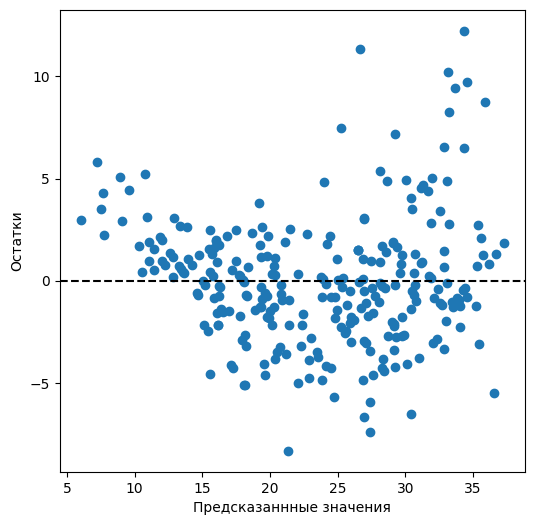

In [1275]:
ax = plt.subplots(figsize = (6, 6))[1]
ax.scatter(result_from_all_params.fittedvalues, result_from_all_params.resid)
ax.set_xlabel('Предсказаннные значения')
ax.set_ylabel('Остатки')
ax.axhline(0, c='k', ls='--');

По графику остатков можно сделать вывод, что отклик зависит нелинейно от предикторов.

Text(0, 0.5, 'Критерий разбалансировки')

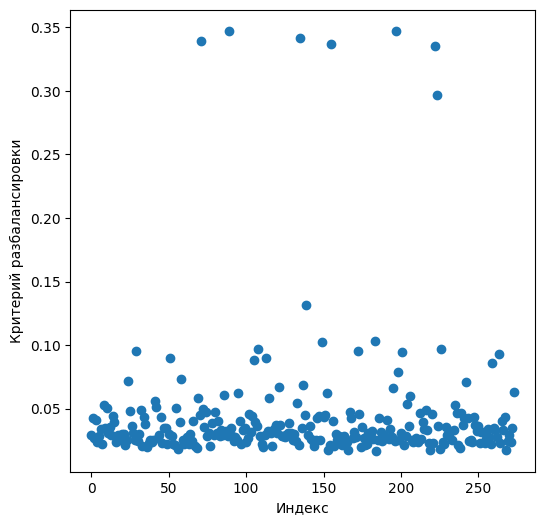

In [1276]:
infl = result_from_all_params.get_influence()
ax = plt.subplots(figsize = (6,6))[1]
ax.scatter(np.arange(X_train.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Индекс')
ax.set_ylabel('Критерий разбалансировки')

Опираясь на график, можно сделать вывод, что у нас есть несколько выбросов.

In [1277]:
(len(X.columns))/ X_train.shape[0]

0.043795620437956206

(e) Выполните несколько подгонок модели с участием эффектов взаимодействия, как было описано в лабораторной работе. Если ли среди этих эффектов статистически значимые?

In [1278]:
auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [1279]:
X = MS(['year', 'horsepower', 'weight',('year', 'horsepower'), ('weight', 'year')]).fit_transform(auto)
y = auto['mpg']

In [1280]:
X.head()

,intercept,year,horsepower,weight,year:horsepower,weight:year
name,,,,,,
chevrolet chevelle malibu,1.0,70,130,3504,9100.0,245280.0
buick skylark 320,1.0,70,165,3693,11550.0,258510.0
plymouth satellite,1.0,70,150,3436,10500.0,240520.0
amc rebel sst,1.0,70,150,3433,10500.0,240310.0
ford torino,1.0,70,140,3449,9800.0,241430.0


In [1281]:
y.head()

name
chevrolet chevelle malibu    18.0
buick skylark 320            15.0
plymouth satellite           18.0
amc rebel sst                16.0
ford torino                  17.0
Name: mpg, dtype: float64

In [1282]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [1283]:
model3 = sm.OLS(y_train, X_train)
result3 = model3.fit()

In [1284]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     455.7
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           4.55e-60
Time:                        17:27:31   Log-Likelihood:                -823.78
No. Observations:                 274   AIC:                             1652.
Df Residuals:                     272   BIC:                             1659.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     41.0848      0.869     47.255      0.0

In [1285]:
pred = result3.predict(X_test)

In [1286]:
MSE = mean_squared_error(y_test, pred)
MSE

7.898855118885691

In [1287]:
np.sqrt(MSE) / y.mean()

0.11987119241340691

Среди эффектов взаимодействия только year:horsepower - имеет низкое p-значение, а значит является статистически значимым.

(f) Попробуйте использовать в модели разные преобразования пееременных, такик как log(x), sqrt(x) или X^2. Прокомментируйте результаты.

In [1288]:
X = MS([poly('displacement', 2), poly('horsepower', 2) , poly('weight', 2), 'acceleration', 'year']).fit_transform(auto)
y = auto['mpg']

In [1289]:
X.head()

,intercept,"poly(displacement, degree=2)[0]","poly(displacement, degree=2)[1]","poly(horsepower, degree=2)[0]","poly(horsepower, degree=2)[1]","poly(weight, degree=2)[0]","poly(weight, degree=2)[1]",acceleration,year
name,,,,,,,,,
chevrolet chevelle malibu,1.0,0.054411,-0.035077,0.033544,-0.052723,0.031342,-0.049352,12.0,70
buick skylark 320,1.0,0.075192,0.010404,0.079529,-0.009329,0.042595,-0.038237,11.5,70
plymouth satellite,1.0,0.059727,-0.025350,0.059821,-0.036300,0.027293,-0.052070,11.0,70
amc rebel sst,1.0,0.052962,-0.037502,0.059821,-0.036300,0.027115,-0.052175,12.0,70
ford torino,1.0,0.051995,-0.039065,0.046682,-0.047302,0.028067,-0.051603,10.5,70


In [1290]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [1291]:
model4 = sm.OLS(y_train, X_train)
result = model4.fit()

In [1292]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     220.1
Date:                Thu, 24 Oct 2024   Prob (F-statistic):          2.38e-112
Time:                        17:27:31   Log-Likelihood:                -679.94
No. Observations:                 274   AIC:                             1378.
Df Residuals:                     265   BIC:                             1410.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
intercept 

In [1293]:
MSE = mean_squared_error(y_test, pred)
MSE

7.898855118885691

In [1294]:
np.sqrt(MSE) / y.mean()

0.11987119241340691

### Задание 10.

Это упражнение должно быть выполнено с использованием набора данных Carseats.

(a) Выполните подгонку множественной регрессионной модели для предсказания отклика Sales с использованием предеотора Prise, Urban и US.

In [1295]:
carseats = load_data('Carseats')

In [1296]:
carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [1297]:
carseats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Sales        400 non-null    float64 
 1   CompPrice    400 non-null    int64   
 2   Income       400 non-null    int64   
 3   Advertising  400 non-null    int64   
 4   Population   400 non-null    int64   
 5   Price        400 non-null    int64   
 6   ShelveLoc    400 non-null    category
 7   Age          400 non-null    int64   
 8   Education    400 non-null    int64   
 9   Urban        400 non-null    category
 10  US           400 non-null    category
dtypes: category(3), float64(1), int64(7)
memory usage: 26.7 KB


In [1298]:
pd.get_dummies(carseats, drop_first= True).corr()['Sales'].sort_values()

Price              -0.444951
Age                -0.231815
ShelveLoc_Medium   -0.073999
Education          -0.051955
Urban_Yes          -0.015419
Population          0.050471
CompPrice           0.064079
Income              0.151951
US_Yes              0.177093
Advertising         0.269507
ShelveLoc_Good      0.500510
Sales               1.000000
Name: Sales, dtype: float64

In [1299]:
X = MS(['Price', 'Urban', 'US']).fit_transform(carseats)
X = pd.get_dummies(X, drop_first = True)
y = carseats['Sales']

In [1300]:
X.head()

,intercept,Price,Urban[Yes],US[Yes]
0,1.0,120,1.0,1.0
1,1.0,83,1.0,1.0
2,1.0,80,1.0,1.0
3,1.0,97,1.0,1.0
4,1.0,128,1.0,0.0


In [1301]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [1302]:
car_model_1 = sm.OLS(y_train, X_train)
car_result_1 = car_model_1.fit()

In [1303]:
print(car_result_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     29.36
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           1.67e-16
Time:                        17:27:31   Log-Likelihood:                -643.66
No. Observations:                 280   AIC:                             1295.
Df Residuals:                     276   BIC:                             1310.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0753      0.758     17.240      0.0

In [1304]:
pred = car_result_1.predict(X_test)

In [1305]:
MSE = mean_squared_error(y_test, pred)

In [1306]:
np.sqrt(MSE)

2.5799326159540987

In [1307]:
y_test.mean()

7.824583333333333

In [1308]:
np.sqrt(MSE) / y_test.mean() * 100

32.972140573458844

(b) Предложите свою интерпретацию каждого коэффициента в модели.

> Судя по p-значениям в данной модели можно выделить price, US[Yes], как статистически важные предикторы.

(c) Опишите модель в виде уравнения.

> y = 13.0753 + -0.0544 * Price  - 0.0647 * Urban[Yes] + 1.0520 * US[Yes]

(d) Для какого из предикторов можно отклонить нулевую гипотезу?

> Нулевую гипотезу можно отклонить для двух предикторов: Price, US[Yes] 

(e) На основе ответа на предудущий вопрос выполните подгонку сокращенной модели, в которой будут присутствовать только предикторы, явно влияющие на отклик.

In [1309]:
X = MS(['Price', 'US']).fit_transform(carseats)
X = pd.get_dummies(X, drop_first = True)
y = carseats['Sales']

In [1310]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [1311]:
car_model_2 = sm.OLS(y_train, X_train)
car_result_2 = car_model_2.fit()

In [1312]:
print(car_result_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     44.17
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           2.24e-17
Time:                        17:27:31   Log-Likelihood:                -643.69
No. Observations:                 280   AIC:                             1293.
Df Residuals:                     277   BIC:                             1304.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0402      0.738     17.678      0.0

In [1313]:
MSE = mean_squared_error(y_test, pred)

In [1314]:
np.sqrt(MSE) / y_test.mean() * 100

32.972140573458844

(f) Насколько хороши модели из (a) и (e).

> В целом обе модели показывают себя плохо. Они в среднем ошибаются в своих предсказаниях на 30% процентов и описывают только 24% процента дисперсии.

(g) На основе модели (e) постройте 95-процентные доверительные интервалы для коэффициентов.

In [1315]:
car_result_2.conf_int(alpha = 0.05)

,0,1
intercept,11.588077,14.492249
Price,-0.066422,-0.042402
US[Yes],0.458259,1.636196


(h) Присутствуют ли в модели (e) выбросы или наблюдения с высокой разбалансировкой?

<Axes: ylabel='Sales'>

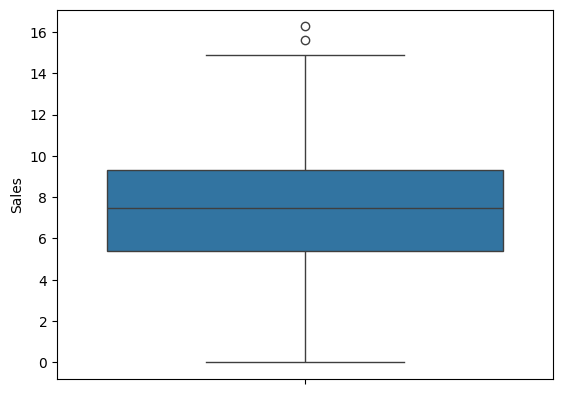

In [1316]:
sns.boxplot(y)

Text(0, 0.5, 'Критерий разбалансировки')

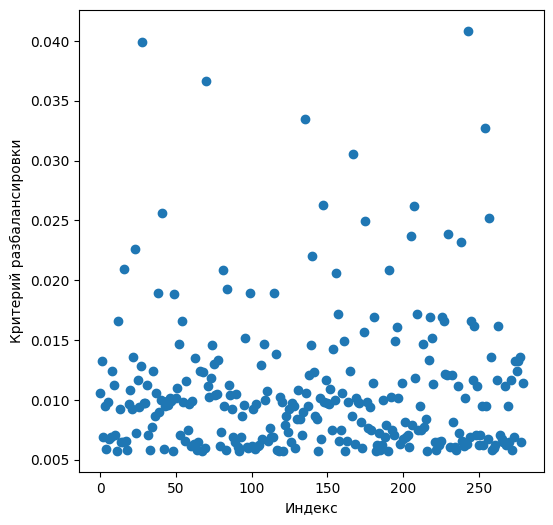

In [1317]:
infl = car_result_2.get_influence()
ax = plt.subplots(figsize = (6,6))[1]
ax.scatter(np.arange(X_train.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Индекс')
ax.set_ylabel('Критерий разбалансировки')

Про графику видно, что у нас есть несбалансированые данные по предиктору.
Также у нас есть пара выбросов

### Задание 11.

В этой задаче мы исследуем t-критерий для нулевой гипотезы H0: B=0 применительно к простой линейно регресси без свободного члена.

In [1318]:
rng = np.random.default_rng(1)
x = rng.normal(size = 100)
y = 2*x + rng.normal(size = 100)

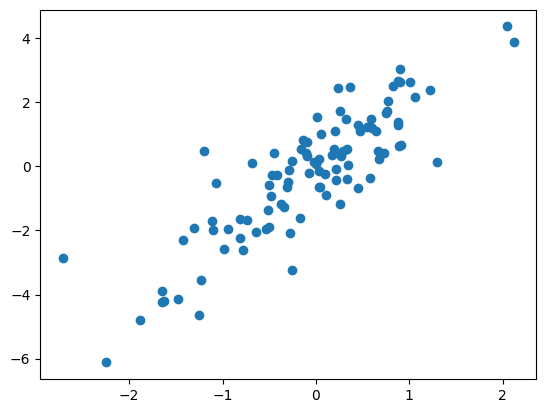

In [1319]:
plt.scatter(x, y)

(a) Выполните простую линейную регрессию отклика y по предиктору x без свободного члена. Определите оценку коэффициента B, стандартную ошибку этой оценки, а также t-критерий и p-значение, связанные с нулевой гипотезой. Прокомментируйте полученные результаты.

In [1320]:
model11 = sm.OLS(y, x)
result11 = model11.fit()

In [1321]:
print(result11.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Thu, 24 Oct 2024   Prob (F-statistic):                    6.23e-31
Time:                        17:27:31   Log-Likelihood:                         -141.35
No. Observations:                 100   AIC:                                      284.7
Df Residuals:                      99   BIC:                                      287.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

> При измение x на одну еденицу целевая переменная меняется, на 1.9762. Также судя по значению t-критерию можно опровергнуть нулевую гипотезу.

(b) Теперь выполните простую линейную регрессия отклика x по предиктору y без свободного членая и определите все теже показатели из предыдущего задания для нулевой гипотезы H0: B=0.

In [1322]:
model12 = sm.OLS(x, y)
result12 = model12.fit()

In [1323]:
print(result12.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Thu, 24 Oct 2024   Prob (F-statistic):                    6.23e-31
Time:                        17:27:31   Log-Likelihood:                         -58.349
No. Observations:                 100   AIC:                                      118.7
Df Residuals:                      99   BIC:                                      121.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

> При измение y на одну еденицу целевая переменная меняется, на 0.3757. Также судя по значению t-критерию можно опровергнуть нулевую гипотезу.

(c) Какая связь наблюдается между результатами, полученным в (a) и (b)?

> Они эквивалентны.

(d) Для регрессии Y по X без участия свободного, докажите алгебраически, что:

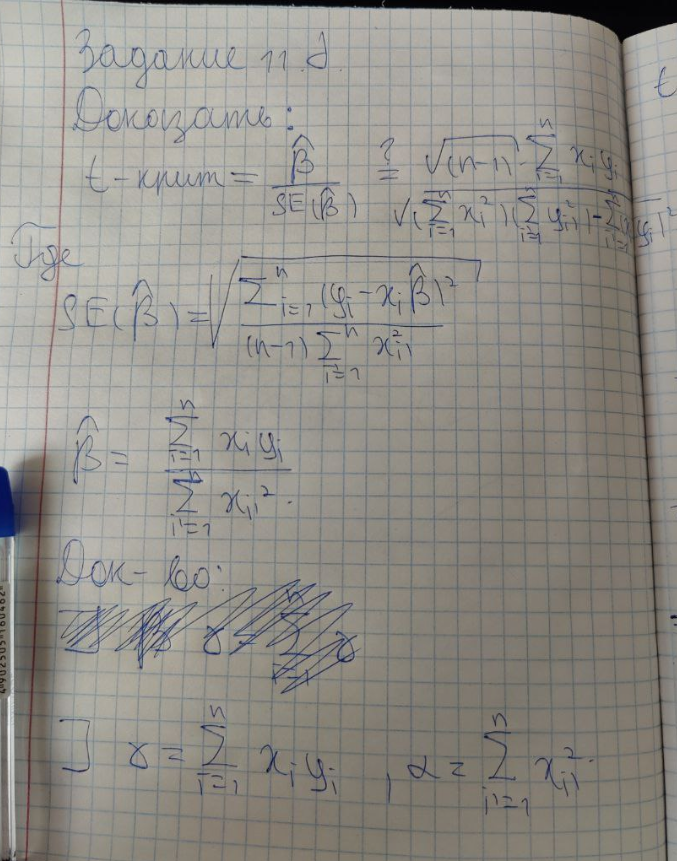

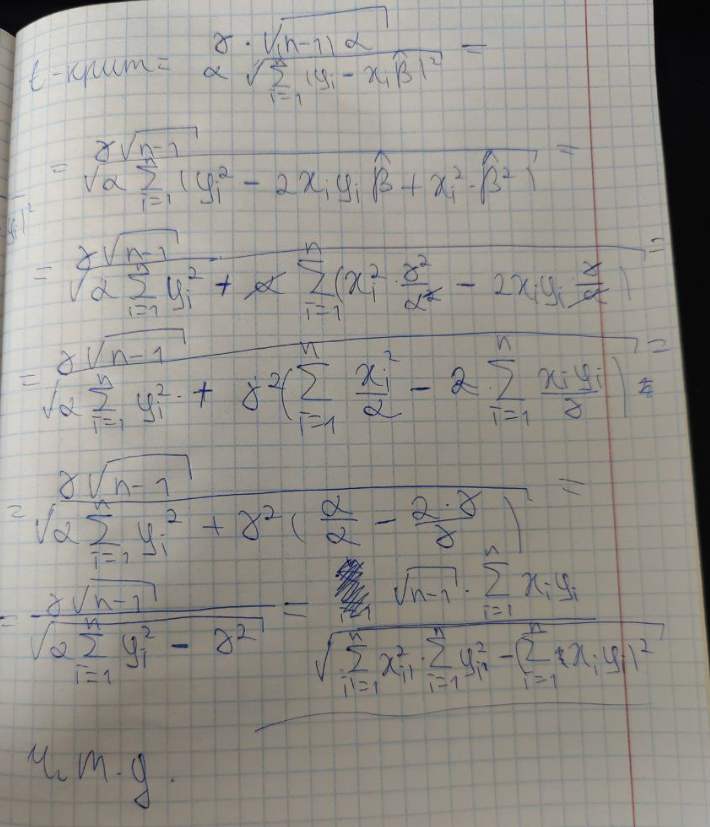

(e) Используя результаты (d), докажите, что значения t-критериев регресси y по x и x по y будут одинаковы.

> Это очевидно если взглянуть на форму для t-критерия из пунка (d).

(f) Покажите на примере в Python, что при участии свободного члена значение t-критерия для H0: B1 = 0 будет одинаковы для регресси y по x и x по y.

In [1324]:
df = pd.DataFrame(data = np.transpose([x, y]), columns = ['x', 'y'])

In [1325]:
X1 = MS(['x']).fit_transform(df)
Y1 = df['y']

In [1326]:
Y2 = MS(['y']).fit_transform(df)
X2 = df['x']

In [1327]:
model_a = sm.OLS(Y1, X1).fit()
model_b = sm.OLS(X2, Y2).fit()

print(model_a.tvalues)
print(model_b.tvalues)

intercept    -0.756096
x            16.734055
dtype: float64
intercept     0.216082
y            16.734055
dtype: float64


### Задание 12.

В этой задаче мы поработаем с простой линейной регрессией без участия свободного члена.

(a) Вспомните, что в (3.38) мы приводили формула для оценки B^ применительно к линейной регрессии Y по X без свободного члена. При каких условиях оценка коэффициента регрессии X по Y будет совпадать с оценкой коэффициента регерсси Y по X?

$$ \sum_{i=1}^n x_i^2 = \sum_{i=1}^n y_i^2$$

(b) Создайте пример в Python для n = 100 наблюдений, в котором оценка коэффициента ргересси X по Y будет отличаться от оценки коэффициента регрессии Y по X.

> Пункты (a) и (b) задания 11.

(c) Создайте пример в Python для n = 100 наблюдений, в котором оценка коэффициента регрессии X по Y будет совоподать с оценкой коэффициента регрессии Y по X.

In [1328]:
rng = np.random.default_rng(1)
x = rng.normal(size = 100)
y = x

In [1329]:
model11 = sm.OLS(y, x)
result11 = model11.fit()

In [1330]:
print(result11.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                                inf
Date:                Thu, 24 Oct 2024   Prob (F-statistic):                        0.00
Time:                        17:27:31   Log-Likelihood:                             inf
No. Observations:                 100   AIC:                                       -inf
Df Residuals:                      99   BIC:                                       -inf
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\statsmodels\regression\linear_model.py:1872: RuntimeWarning: divide by zero encountered in scalar divide
  return self.mse_model/self.mse_resid
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\statsmodels\regression\linear_model.py:958: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\statsmodels\stats\stattools.py:50: RuntimeWarning: invalid value encountered in scalar divide
  dw = np.sum(diff_resids**2, axis=axis) / np.sum(resids**2, axis=axis)


In [1331]:
model12 = sm.OLS(x, y)
result12 = model12.fit()

In [1332]:
print(result12.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                                inf
Date:                Thu, 24 Oct 2024   Prob (F-statistic):                        0.00
Time:                        17:27:31   Log-Likelihood:                             inf
No. Observations:                 100   AIC:                                       -inf
Df Residuals:                      99   BIC:                                       -inf
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\statsmodels\regression\linear_model.py:1872: RuntimeWarning: divide by zero encountered in scalar divide
  return self.mse_model/self.mse_resid
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\statsmodels\regression\linear_model.py:958: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\statsmodels\stats\stattools.py:50: RuntimeWarning: invalid value encountered in scalar divide
  dw = np.sum(diff_resids**2, axis=axis) / np.sum(resids**2, axis=axis)


## Задание 13.

В этом упражнении мы сгенерируем несколько наборов данных и выполним подгонкук ним моделей простой линейной регрессии.

(a) Воспользуетесть метод normal() генератора случайных чисел для создания вектора x, состоящего из 100 наблюдений на основене нормального распределения N(0,1). Это будет на предиктор X.

In [1333]:
X = rng.normal(0, 1, 100)

(b) С помощью того же метода создайте вектор eps длины 100 на основе нормального распределения N(0, 0.25).

In [1334]:
eps = rng.normal(0, 0.5, 100)

(c) Используя переменные x и eps, создайте вектору y, следуя показанной ниже модели:

$$ Y = -1 + 0.5X + eps$$

In [1335]:
y = -1 + 0.5 * X + eps

(d) Постройте диаграмму рассеяния, демонстрирущую взаимосвязь между X и Y.

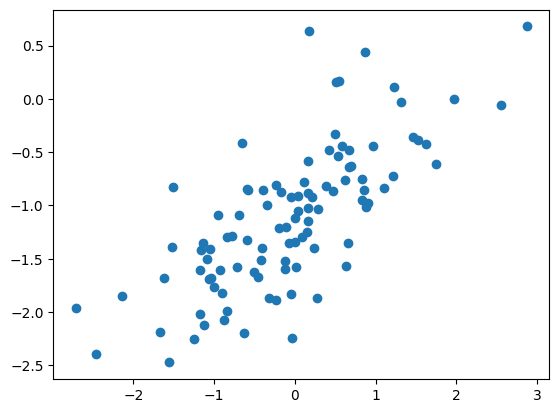

In [1336]:
plt.scatter(X, y)

По диаграмме видно, что у нас есть линейная связь между X и Y.

(e) Выполните подгонку линейной модели по методу наименьших кавдратов для предсказания y по X.

In [1337]:
X = pd.DataFrame(data = X, columns = ['x'])

In [1338]:
X.head()

,x
0,-0.651281
1,0.862445
2,-0.125592
3,0.669153
4,1.218844


In [1339]:
data1 = MS('x').fit_transform(X)

In [1340]:
data1

,intercept,x
0,1.0,-0.651281
1,1.0,0.862445
2,1.0,-0.125592
3,1.0,0.669153
4,1.0,1.218844
...,...,...
95,1.0,-1.617467
96,1.0,1.109638
97,1.0,0.168106
98,1.0,0.548405


In [1341]:
model12 = sm.OLS(y, data1)
result12 = model12.fit()

In [1342]:
print(result12.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     112.5
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           5.83e-18
Time:                        17:27:31   Log-Likelihood:                -63.477
No. Observations:                 100   AIC:                             131.0
Df Residuals:                      98   BIC:                             136.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0810      0.046    -23.378      0.0

(f) Отобразите на графике, полученном в (d), линию наименьших кадратов. Выведите линию регресси генеральной совокупности другим цветом.

In [1343]:
gen_line = lambda x: -1 + 0.5 * x

C:\Users\10\AppData\Local\Temp\ipykernel_210528\3031615537.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, result12.params[0], result12.params[1], color = 'orange')


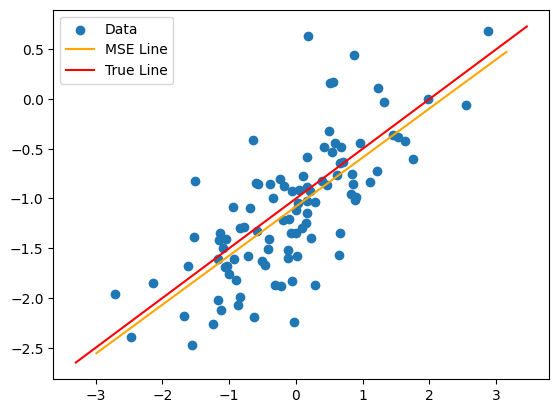

In [1344]:
fig, ax = plt.subplots()
ax.scatter(X, y)
abline(ax, result12.params[0], result12.params[1], color = 'orange')
abline(ax, -1, 0.5, color = 'red')
ax.legend(['Data', 'MSE Line', 'True Line'])

In [1345]:
y_predict = result12.predict(data1)

In [1346]:
MSE = mean_squared_error(y, y_predict)
print(f'RMSE: {np.sqrt(MSE)}')

RMSE: 0.4565002396974797


(g) Теперь выполните подгонку полиномиальной регрессионной моедли к аднным для предсказания y по x и x^2. Если доказательсва того, что модель прибавила в качестве? 

In [1347]:
X

,x
0,-0.651281
1,0.862445
2,-0.125592
3,0.669153
4,1.218844
...,...
95,-1.617467
96,1.109638
97,0.168106
98,0.548405


In [1348]:
data2 = MS([poly('x', degree=2)]).fit_transform(X)

In [1349]:
data2

,intercept,"poly(x, degree=2)[0]","poly(x, degree=2)[1]"
0,1.0,-0.058219,-0.037131
1,1.0,0.094365,-0.015696
2,1.0,-0.005229,-0.063595
3,1.0,0.074881,-0.035095
4,1.0,0.130290,0.032864
...,...,...,...
95,1.0,-0.155611,0.105611
96,1.0,0.119282,0.016222
97,1.0,0.024375,-0.062670
98,1.0,0.062710,-0.044738


In [1350]:
model13 = sm.OLS(y, data2)
result13 = model13.fit()

In [1351]:
print(result13.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     56.40
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           5.63e-17
Time:                        17:27:31   Log-Likelihood:                -63.135
No. Observations:                 100   AIC:                             132.3
Df Residuals:                      97   BIC:                             140.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -1.1173 

In [1352]:
y_predict = result13.predict(data2)

In [1353]:
MSE = mean_squared_error(y, y_predict)
print(f'RMSE: {np.sqrt(MSE)}')

RMSE: 0.45494180411489415


По метрика можно сделать, что линейная модель справляется лучше, а полиномиальная модель переобучилась.

## Задание 14.

В этом упражнении мы поработаем со свойством коллинеарности.

(a) Выполните следующий фрагмент кода в Python:

In [1354]:
rng = np.random.default_rng(100)
x1 = rng.uniform(0, 1, size = 100)
x2 = 0.5 * x1 + rng.normal(size = 100) / 10
y = 2 + 2*x1 + 0.3 * x2 + rng.normal(size = 100)

(b) Какова корреляция между переменными x1 и x2? постройте диаграмму рассеяния, показывающую взаимосвязь между переменными.

In [1355]:
[x1, x2]

[array([0.83498163, 0.59655403, 0.28886324, 0.04295157, 0.9736544 ,
        0.5964717 , 0.79026316, 0.91033938, 0.68815445, 0.18999147,
        0.98147898, 0.28474005, 0.62927317, 0.58103648, 0.59991227,
        0.53524811, 0.9957771 , 0.50194608, 0.77102258, 0.49416178,
        0.99767449, 0.97862192, 0.39356804, 0.32192526, 0.86218065,
        0.7993249 , 0.69143063, 0.40851785, 0.38976513, 0.1316484 ,
        0.62549749, 0.08240137, 0.27457299, 0.65611703, 0.01467603,
        0.83453217, 0.07239908, 0.52412082, 0.54655052, 0.22724696,
        0.95597822, 0.34096385, 0.50470744, 0.86738361, 0.65695295,
        0.38472241, 0.09627241, 0.95580562, 0.58956713, 0.58216289,
        0.59714527, 0.14887393, 0.56004863, 0.56316752, 0.58098818,
        0.184949  , 0.70961891, 0.07002066, 0.32486494, 0.10685547,
        0.74802869, 0.50157401, 0.4663081 , 0.07369337, 0.44209638,
        0.22351108, 0.30297573, 0.39434801, 0.70663065, 0.78636314,
        0.3568361 , 0.67012985, 0.51022312, 0.67

In [1356]:
df = pd.DataFrame(data = np.array([x1, x2, y]).transpose(), columns = ['x1', 'x2', 'y'])

In [1357]:
df

,x1,x2,y
0,0.834982,0.434307,4.045840
1,0.596554,0.229314,0.389863
2,0.288863,0.202021,3.446374
3,0.042952,0.021732,2.347697
4,0.973654,0.594844,2.072421
...,...,...,...
95,0.508768,0.109973,2.167398
96,0.860642,0.451566,5.352174
97,0.504046,0.141322,3.171650
98,0.288253,0.207752,1.553058


In [1358]:
df.corr()

,x1,x2,y
x1,1.000000,0.845148,0.410691
x2,0.845148,1.000000,0.365488
y,0.410691,0.365488,1.000000


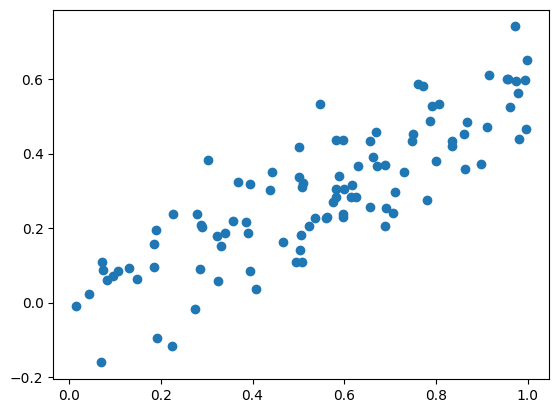

In [1359]:
plt.scatter(df['x1'], df['x2'])

(c) Используя полученные данные, выполните подгонку по методу наименьших квадратов для предсказанаия y на основе x1, x2. Опишите полученные результаты. Можем ли мы отклонить нулевую гипотезу H0: B1 = 0? А как насчет нулевой гипотезы H0: B2 = 0?

In [1360]:
model14 = sm.OLS(y, df.drop(labels = 'y', axis = 1))

In [1361]:
result14 = model14.fit()

In [1362]:
print(result14.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.825
Model:                            OLS   Adj. R-squared (uncentered):              0.822
Method:                 Least Squares   F-statistic:                              231.5
Date:                Thu, 24 Oct 2024   Prob (F-statistic):                    7.39e-38
Time:                        17:27:31   Log-Likelihood:                         -170.21
No. Observations:                 100   AIC:                                      344.4
Df Residuals:                      98   BIC:                                      349.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Т.к. p-значение для x1 невелико мы можем отклонить нулевую гипотезу H0: B0 = 0. Однако гипотезу H0: B1 = 0 отклонить нельзя.

(d) Выполните подгонку по методу наименьших квадратов только на основе x1. Какие результаты получились? Можно ли отклонить H0:B0 = 0?

In [1363]:
model15 = sm.OLS(y, df.drop(labels = ['y', 'x2'], axis = 1))
result15 = model15.fit()

In [1364]:
print(result15.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.825
Model:                            OLS   Adj. R-squared (uncentered):              0.823
Method:                 Least Squares   F-statistic:                              466.8
Date:                Thu, 24 Oct 2024   Prob (F-statistic):                    2.97e-39
Time:                        17:27:31   Log-Likelihood:                         -170.30
No. Observations:                 100   AIC:                                      342.6
Df Residuals:                      99   BIC:                                      345.2
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

p-значение для x1 мало => можно отклонить нулевую гипотезу.

(e) Выполните подгонку по методу наименьших квадратов только на основе x2. Какие результаты получились? Можно ли отклонить H0:B1 = 0?

In [1365]:
model16 = sm.OLS(y, df.drop(labels = ['y', 'x1'], axis = 1))
result16 = model16.fit()

In [1366]:
print(result16.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.750
Model:                            OLS   Adj. R-squared (uncentered):              0.748
Method:                 Least Squares   F-statistic:                              297.5
Date:                Thu, 24 Oct 2024   Prob (F-statistic):                    1.36e-31
Time:                        17:27:31   Log-Likelihood:                         -188.07
No. Observations:                 100   AIC:                                      378.1
Df Residuals:                      99   BIC:                                      380.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

p-значение для x2 мало => можно отклонить нулевую гипотезу.

(f) Противоречят ли друг другу результаты, полученные в (c) - (e)?

> Да, противоречат. Т.к в (c) нельзя было опровергнуть H0: B1 = 0, а в (d) ее получилось опровергнуть.

(g) Предположим, у нас появилось одно дополнительное наблюдение, которое ранее, к сожалению было измерено неверно. Воспользуемся функцией np.concatenate() для добавления этого наблюдения в переменные x1, x2 и y.

In [1367]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

Заново выполните подгонку линейных моделей из (с) - (e) на основе новых данных? является ли оно выбросом в наших моделях? Обладает высокой разбалансировкой? Может, и то и другое?

In [1368]:
df = pd.DataFrame(data = np.array([x1, x2, y]).transpose(), columns = ['x1', 'x2', 'y'])

In [1369]:
model14 = sm.OLS(y, df.drop(labels = 'y', axis = 1))
result14 = model14.fit()

In [1370]:
influence = result14.get_influence()
studentized_residuals = influence.resid_studentized_internal
df[np.abs(studentized_residuals) > 3]

,x1,x2,y
100,0.1,0.8,6.0


In [1371]:
leverage = influence.hat_matrix_diag
df[(leverage > 1/len(df) - 1/len(df)*7) & (leverage > 1/len(df) + 1/len(df)*7)]

,x1,x2,y
100,0.1,0.8,6.0


In [1372]:
print(result14.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.810
Model:                            OLS   Adj. R-squared (uncentered):              0.806
Method:                 Least Squares   F-statistic:                              210.8
Date:                Thu, 24 Oct 2024   Prob (F-statistic):                    2.07e-36
Time:                        17:27:31   Log-Likelihood:                         -177.47
No. Observations:                 101   AIC:                                      358.9
Df Residuals:                      99   BIC:                                      364.2
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

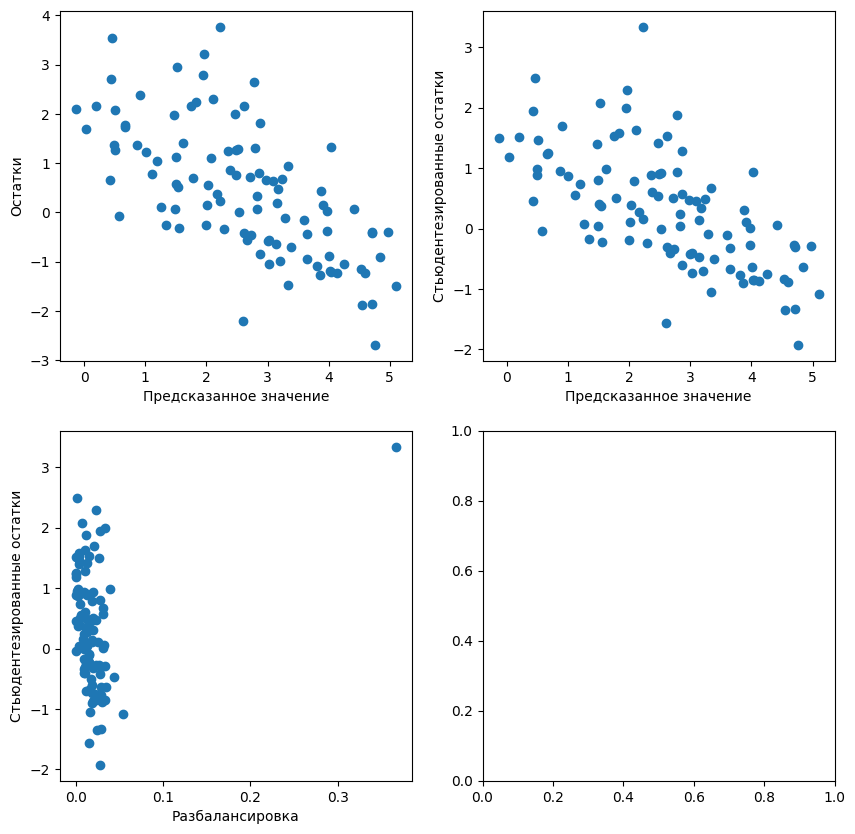

In [1373]:
draw_inf(result14, df.drop(labels = 'y', axis = 1), df['y'])

Для модели только с x1 и x2 точка (0.1, 0.8, 6) будет как разбалансированной, так и выбросом. Такой вывод можно сделать посмотрев на стьюдентизированный остаток и разбалансированость точки.

In [1374]:
model15 = sm.OLS(y, df.drop(labels = ['y', 'x2'], axis = 1))
result15 = model15.fit()

In [1375]:
influence = result15.get_influence()
studentized_residuals = influence.resid_studentized_internal
df[np.abs(studentized_residuals) > 3]

,x1,x2,y
100,0.1,0.8,6.0


In [1376]:
leverage = influence.hat_matrix_diag
df[(leverage > 1/len(df) - 1/len(df)*7) & (leverage > 1/len(df) + 1/len(df)*7)]

,x1,x2,y


In [1377]:
print(result15.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.802
Model:                            OLS   Adj. R-squared (uncentered):              0.800
Method:                 Least Squares   F-statistic:                              404.6
Date:                Thu, 24 Oct 2024   Prob (F-statistic):                    6.34e-37
Time:                        17:27:32   Log-Likelihood:                         -179.56
No. Observations:                 101   AIC:                                      361.1
Df Residuals:                     100   BIC:                                      363.7
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

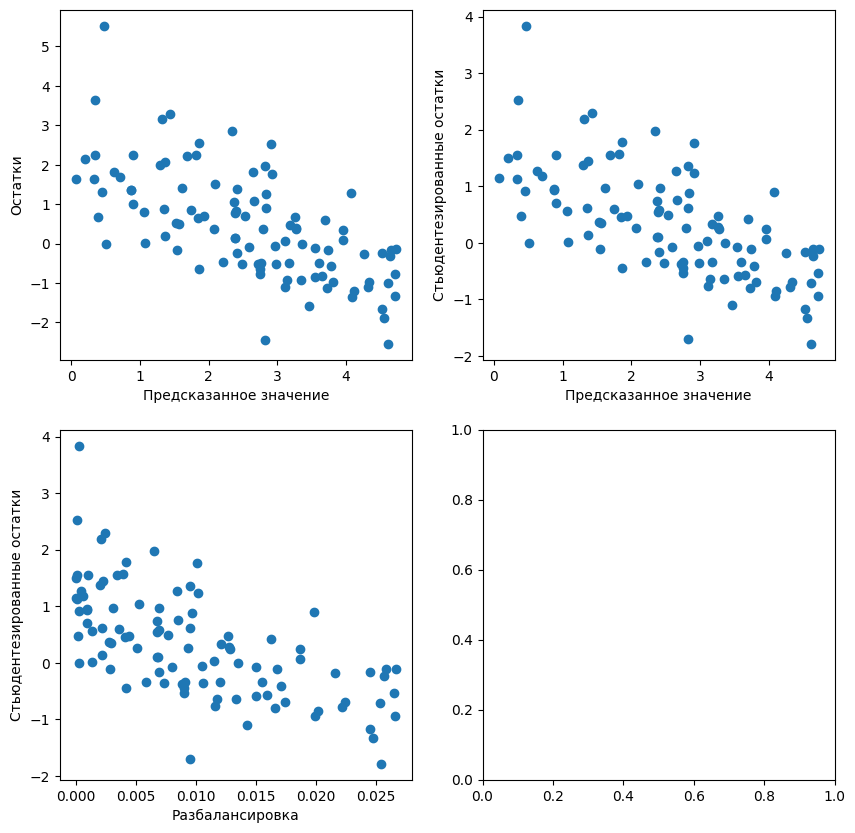

In [1378]:
draw_inf(result15, df.drop(labels = ['y', 'x2'], axis = 1), df['y'])

Для модели только с x2 точка (0.1, 0.8, 6) будет выбросом. Такой вывод можно сделать посмотрев на стьюдентизированный остаток и разбалансированость точки.

In [1379]:
model16 = sm.OLS(y, df.drop(labels = ['y', 'x1'], axis = 1))
result16 = model16.fit()

In [1380]:
influence = result16.get_influence()
studentized_residuals = influence.resid_studentized_internal
df[np.abs(studentized_residuals) > 3]

,x1,x2,y


In [1381]:
leverage = influence.hat_matrix_diag
df[(leverage > 1/len(df) - 1/len(df)*7) & (leverage > 1/len(df) + 1/len(df)*7)]

,x1,x2,y


In [1382]:
print(result16.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.759
Model:                            OLS   Adj. R-squared (uncentered):              0.756
Method:                 Least Squares   F-statistic:                              314.7
Date:                Thu, 24 Oct 2024   Prob (F-statistic):                    1.19e-32
Time:                        17:27:32   Log-Likelihood:                         -189.47
No. Observations:                 101   AIC:                                      380.9
Df Residuals:                     100   BIC:                                      383.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

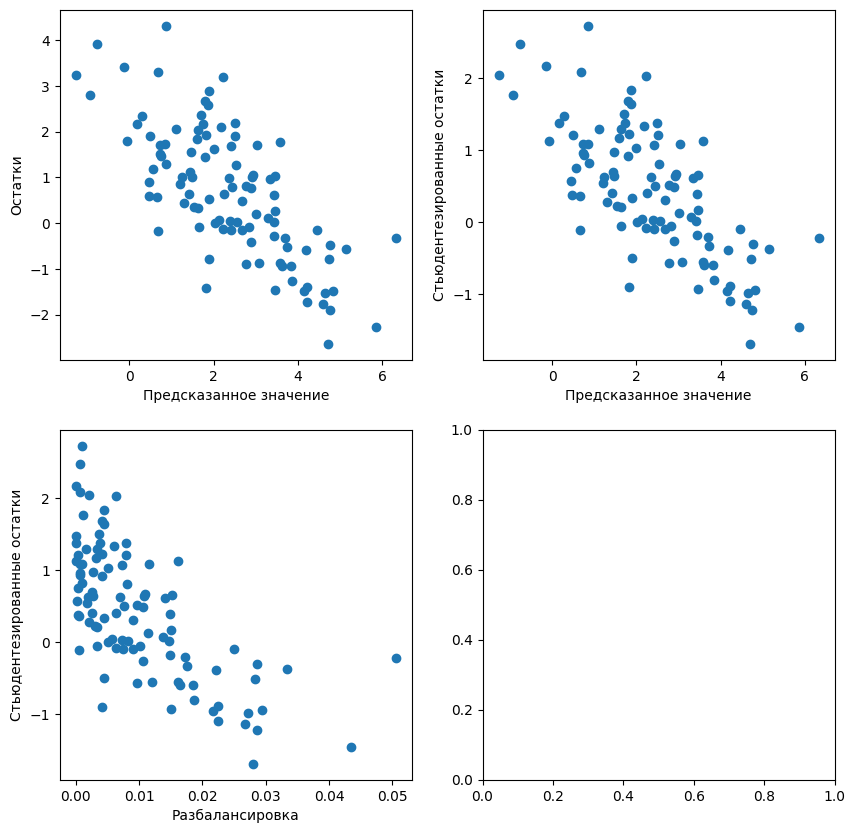

In [1383]:
draw_inf(result16, df.drop(labels = ['y', 'x1'], axis = 1), df['y'])

Для модели только с x1 точка (0.1, 0.8, 6) будет обычной. Такой вывод можно сделать посмотрев на стьюдентизированный остаток и разбалансированость точки.

## Задание 15.

В этом упражнении мы поработаем с набором данных Boston. Уровень преступности будет откликом, а остальные переменные - предикторами.

(a) Выполните подгонку линейной модели для каждого предиктора в отдельности для пресдказания отклика. Опишите полученные результаты. В каких моделях мы получили статистические значимые зависимости между предиктором и откликом?

In [1384]:
boston = pd.read_csv('../DataSets/Boston.csv')


In [1385]:
boston = boston.drop('Unnamed: 0', axis = 1)

In [1386]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [1387]:
X = boston.drop('crim', axis = 1)
y = boston['crim']
coef_one_par_models = pd.Series()

In [1388]:
for c in X.columns:
    model = sm.OLS(y, MS([c]).fit_transform(X))
    result = model.fit()
    coef_one_par_models[c] = result.params[c]
    print(f'Модель где в качестве предиктора использовался столбей {c}')
    print(result.summary())

Модель где в качестве предиктора использовался столбей zn
                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     21.10
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           5.51e-06
Time:                        17:27:32   Log-Likelihood:                -1796.0
No. Observations:                 506   AIC:                             3596.
Df Residuals:                     504   BIC:                             3604.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [1389]:
boston.corr()['crim'].sort_values()

medv      -0.388305
dis       -0.379670
rm        -0.219247
zn        -0.200469
chas      -0.055892
ptratio    0.289946
age        0.352734
indus      0.406583
nox        0.420972
lstat      0.455621
tax        0.582764
rad        0.625505
crim       1.000000
Name: crim, dtype: float64

> * zn - не статистически важный предиктор.
> * indus - статистически важный предиктор.
> * chas - не статистически важный предиктор.
> * nox - cтатистически важный предиктор.
> * rm - статистически важный предиктор.
> * age - статистически важный предиктор.
> * dis - статистически важный предиктор.
> * rad - cтатистически важный предиктор.
> * tax - статистически важный предиктор.
> * ptratio - статистически важный предиктор.
> * lstat - статистически важный предиктор.
> * medv - статистически важный предиктор.

(b) Выполните подгонку с помощью множественной линейной регресси.

In [1399]:
model = sm.OLS(y, MS(X.columns).fit_transform(X))
result = model.fit()

In [1400]:
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           2.03e-56
Time:                        17:29:16   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.7784      7.082      1.946      0.0

Среди наших предикторов есть коллинеарность. Такой вывод можно сделать взгялну на то, как изменились некторые p-значения.

Нулевую гипотезу можно опровергнуть для предикторов: dis, rad, lstat, medv, zn, rm.

In [1401]:
result.params

intercept    13.778394
zn            0.045710
indus        -0.058350
chas         -0.825378
nox          -9.957587
rm            0.628911
age          -0.000848
dis          -1.012247
rad           0.612465
tax          -0.003776
ptratio      -0.304073
lstat         0.138801
medv         -0.220056
dtype: float64

Text(0.5, 0, 'Коэффиценты модели с одним предиктором')

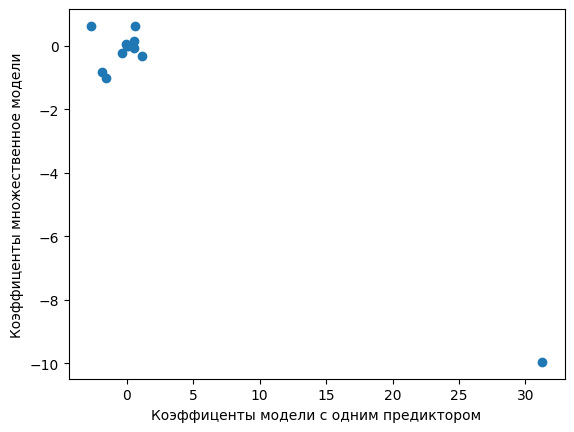

In [1403]:
plt.scatter(x = coef_one_par_models, y = result.params[1:])
plt.ylabel('Коэффиценты множественное модели')
plt.xlabel('Коэффиценты модели с одним предиктором')

(d) Можно ли обнаружить доказательство нелинейности связи между как-либо из предикторов и откликом? Чтобы ответить на этот вопрос постройте следующую модель: $ Y = B0 + B1*X+B2*X^2 + B3*X^3$

In [1405]:
for c in X.columns:
    model = sm.OLS(y, MS([poly(c, degree = 4)]).fit_transform(X))
    result = model.fit()
    print(f'Модель где в качестве предиктора использовался столбец {c}')
    print(result.summary())

Модель где в качестве предиктора использовался столбец zn
                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     7.842
Date:                Thu, 24 Oct 2024   Prob (F-statistic):           3.90e-06
Time:                        17:31:21   Log-Likelihood:                -1791.0
No. Observations:                 506   AIC:                             3592.
Df Residuals:                     501   BIC:                             3613.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

Видно, что от некоторых предикторов целевая переменная зависит нелинейно.